In [2]:
from google.colab import userdata
import os

token = userdata.get('KAGGLE_TOKEN')
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/access_token"), "w") as f:
    f.write(token)
os.chmod(os.path.expanduser("~/.kaggle/access_token"), 0o600)

In [3]:
!pip install -q kaggle
!kaggle datasets list

ref                                                             title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
datascikhan/e-commerce-sales-and-customer-analytics             E-Commerce Sales Analytics Dataset                    29815424  2026-08-25 08:00:46.013000           7871        164                1  
srisyra02/online-food-ordering-dataset                          Online Food Ordering Dataset                              3648  2026-08-23 15:26:25.483000           5303         87                1  
dreaddevelopment/raptor-knee-widedense                          Knee MRI model weights: twelve findings              543320725  2026-08-23 04:12:20.703000           1260         78           0.9375  


In [4]:
!pip install -q --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 5.0 MB/s eta 0:00:00


In [5]:
!kaggle datasets download -d emmarex/plantdisease
!unzip -q plantdisease.zip -d PlantVillage

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:04<00:00, 140MB/s]



In [6]:
import os

DATA_DIR = "PlantVillage/PlantVillage"
classes = os.listdir(DATA_DIR)

print(f"Number of classes: {len(classes)}\n")

for c in classes:
    n = len(os.listdir(os.path.join(DATA_DIR, c)))
    print(f"{c}: {n} images")

Number of classes: 15

Tomato__Tomato_YellowLeaf__Curl_Virus: 3209 images
Tomato_Late_blight: 1909 images
Tomato_healthy: 1591 images
Tomato_Bacterial_spot: 2127 images
Tomato__Tomato_mosaic_virus: 373 images
Tomato_Spider_mites_Two_spotted_spider_mite: 1676 images
Pepper__bell___Bacterial_spot: 997 images
Potato___Early_blight: 1000 images
Pepper__bell___healthy: 1478 images
Potato___Late_blight: 1000 images
Tomato__Target_Spot: 1404 images
Tomato_Early_blight: 1000 images
Tomato_Leaf_Mold: 952 images
Potato___healthy: 152 images
Tomato_Septoria_leaf_spot: 1771 images


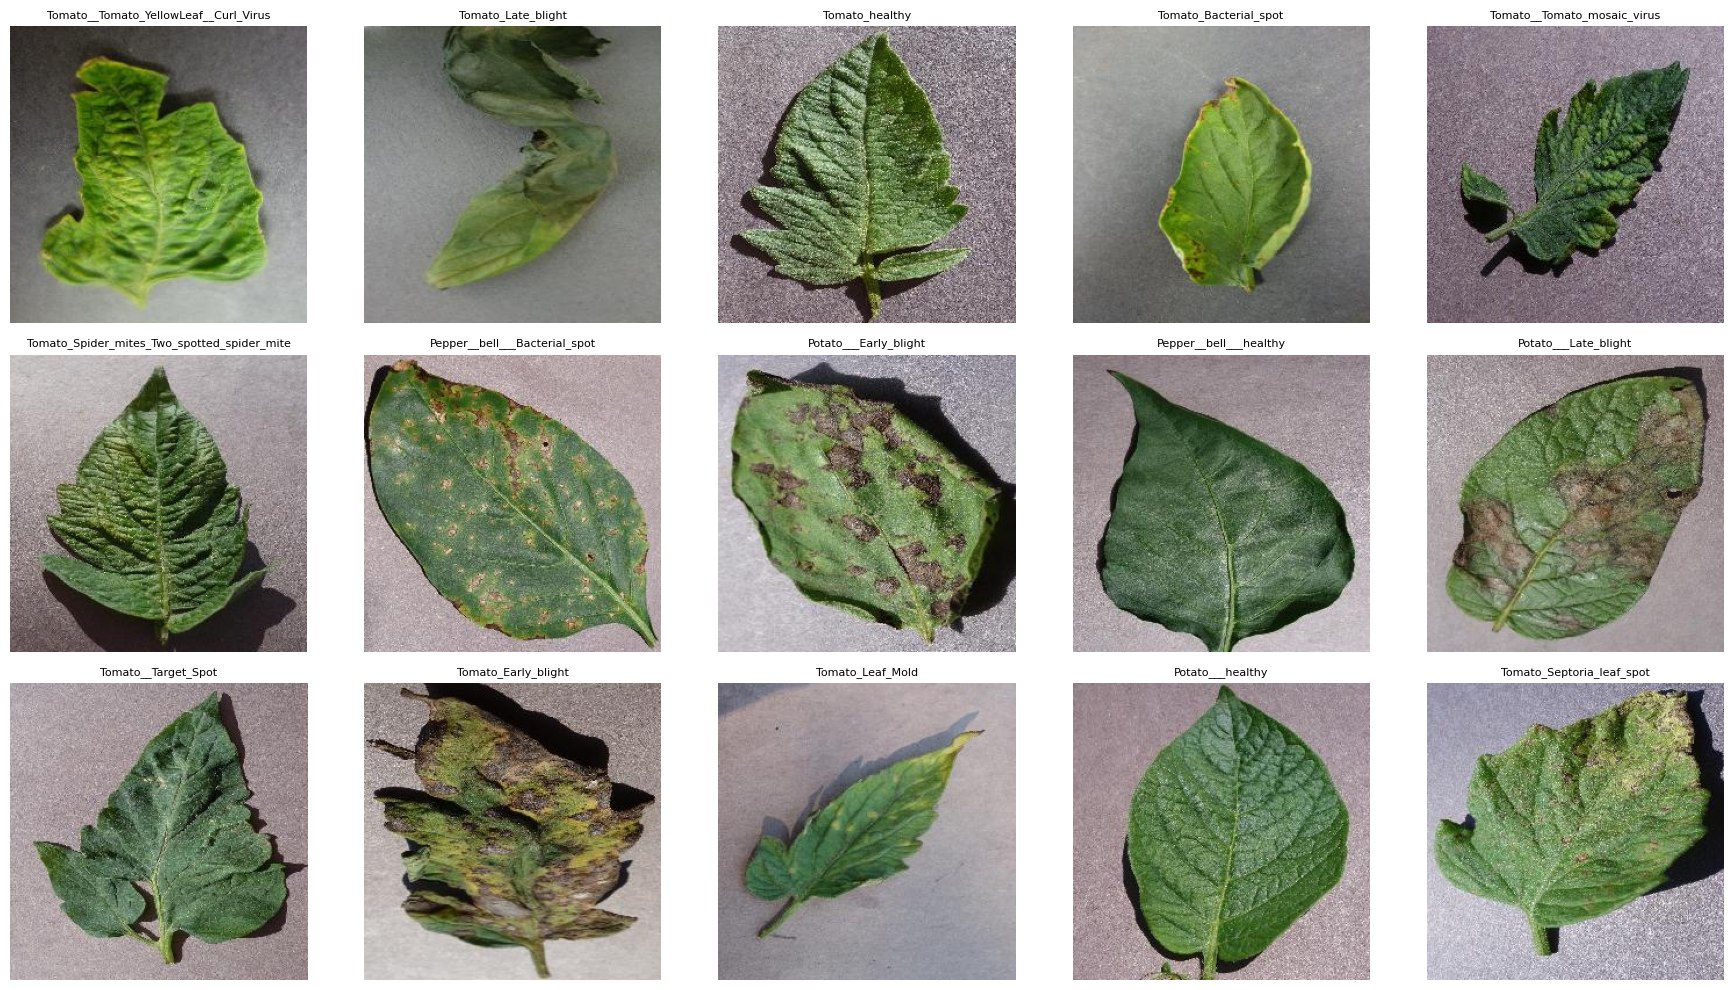

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for ax, c in zip(axes, classes):
    img_path = os.path.join(DATA_DIR, c, os.listdir(os.path.join(DATA_DIR, c))[0])
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(c, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [8]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(class_names)

Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [9]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# Speed up training by prefetching batches while the GPU is busy
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [10]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Get all labels from the training set to compute weights
train_labels = np.concatenate([y for x, y in train_ds], axis=0)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

{0: np.float64(1.3407226958993097), 1: np.float64(0.9188091263216472), 2: np.float64(1.3656741108354011), 3: np.float64(1.418470790378007), 4: np.float64(8.949051490514906), 5: np.float64(0.6425763767269896), 6: np.float64(1.3759166666666667), 7: np.float64(0.7147619047619047), 8: np.float64(1.4794802867383512), 9: np.float64(0.7675964667596467), 10: np.float64(0.8117502458210423), 11: np.float64(0.9827976190476191), 12: np.float64(0.4354166666666667), 13: np.float64(3.681382385730212), 14: np.float64(0.8784783187017824)}


In [12]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.Input(shape=(224, 224, 3)),
    data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(len(class_names), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,277,199 (8.69 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight_dict
)

Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 51s 77ms/step - accuracy: 0.7103 - loss: 0.9527 - val_accuracy: 0.8301 - val_loss: 0.5500
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 37s 72ms/step - accuracy: 0.8318 - loss: 0.5067 - val_accuracy: 0.8592 - val_loss: 0.4440
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 38s 74ms/step - accuracy: 0.8508 - loss: 0.4366 - val_accuracy: 0.8699 - val_loss: 0.4076
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 38s 73ms/step - accuracy: 0.8594 - loss: 0.4063 - val_accuracy: 0.8713 - val_loss: 0.3802
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 41s 79ms/step - accuracy: 0.8724 - loss: 0.3643 - val_accuracy: 0.8854 - val_loss: 0.3593
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 38s 73ms/step - accuracy: 0.8745 - loss: 0.3518 - val_accuracy: 0.8990 - val_loss: 0.3162
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 44s 80ms/step - accuracy: 0.8795 - loss: 0.3379 - val_accuracy: 0.8907 - val_loss: 0.3359
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 38s 73ms/step - accuracy: 0.8842 - loss: 0.3224 - 

In [16]:
model.save("plant_disease_model.keras")

In [17]:
from google.colab import files
files.download("plant_disease_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>